In [1]:
import numpy as np
import pandas as pd

In [2]:
import seaborn as sns
import matplotlib as plt

In [3]:
sns.set_style('darkgrid')
plt.rcParams['figure.figsize']= (8,5)

In [4]:
df = pd.read_csv('6 class csv.csv')

In [5]:
df.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M


In [6]:
df.columns

Index(['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)',
       'Absolute magnitude(Mv)', 'Star type', 'Star color', 'Spectral Class'],
      dtype='str')

In [7]:
df['Star color'].nunique()


19

In [8]:
df['Star color'].value_counts()

Star color
Red                   112
Blue                   55
Blue-white             26
Blue White             10
yellow-white            8
White                   7
Yellowish White         3
Blue white              3
white                   3
Whitish                 2
Orange                  2
yellowish               2
Pale yellow orange      1
White-Yellow            1
Blue                    1
Yellowish               1
Orange-Red              1
Blue white              1
Blue-White              1
Name: count, dtype: int64

In [9]:
df['Star color'] = df['Star color'].str.strip().str.lower()

In [10]:
# *Removing anything that has hyphen in it.*

In [11]:
df['Star color'] = df['Star color'].str.replace('-',' ',regex = False)


In [12]:
# Collapse any repeated internal spaces left over 
# from the previous step.

In [13]:
df['Star color']=df['Star color'].str.split().str.join(' ')

In [14]:
# Make the some changes like white, yellow and white*yellow combo
# to Reduce any confusion

In [15]:
df['Star color'] = df['Star color'].replace({'yellowish white':'yellow white','white yellow':'yellow white'})

In [16]:
df['Star color'].nunique()

10

In [17]:
df

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,red,M
1,3042,0.000500,0.1542,16.60,0,red,M
2,2600,0.000300,0.1020,18.70,0,red,M
3,2800,0.000200,0.1600,16.65,0,red,M
4,1939,0.000138,0.1030,20.06,0,red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,5,blue,O
236,30839,834042.000000,1194.0000,-10.63,5,blue,O
237,8829,537493.000000,1423.0000,-10.73,5,white,A
238,9235,404940.000000,1112.0000,-11.23,5,white,A


In [18]:
# encoding the Star color

In [19]:
from sklearn.preprocessing import LabelEncoder

In [20]:
l = LabelEncoder()

In [21]:
df['Star color'] = l.fit_transform(df['Star color'])

In [22]:
df['Spectral Class'] = l.fit_transform(df['Spectral Class'])

In [23]:
df

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,5,5
1,3042,0.000500,0.1542,16.60,0,5,5
2,2600,0.000300,0.1020,18.70,0,5,5
3,2800,0.000200,0.1600,16.65,0,5,5
4,1939,0.000138,0.1030,20.06,0,5,5
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,5,0,6
236,30839,834042.000000,1194.0000,-10.63,5,0,6
237,8829,537493.000000,1423.0000,-10.73,5,6,0
238,9235,404940.000000,1112.0000,-11.23,5,6,0


In [24]:
df['Star color'].nunique()

10

In [25]:
df['Star color'].value_counts()

Star color
5    112
0     56
1     41
8     12
6     10
9      3
7      2
2      2
4      1
3      1
Name: count, dtype: int64

In [26]:
df = df.drop(columns=['Star color'])

In [27]:
df2 = pd.read_csv("6 class csv.csv")

In [28]:
df['Star color'] = df2['Star color'].str.strip().str.lower().str.replace('-',' ', regex = False)

In [29]:
df['Star color'] = df['Star color'].str.split().str.join(' ').replace({'yellowish white':'yellow white','white yellow':'yellow white'})

In [30]:
df = pd.get_dummies(df,columns=['Star color'],prefix = 'color')

In [31]:
df.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Spectral Class,color_blue,color_blue white,color_orange,color_orange red,color_pale yellow orange,color_red,color_white,color_whitish,color_yellow white,color_yellowish
0,3068,0.002400,0.1700,16.12,0,5,False,False,False,False,False,True,False,False,False,False
1,3042,0.000500,0.1542,16.60,0,5,False,False,False,False,False,True,False,False,False,False
2,2600,0.000300,0.1020,18.70,0,5,False,False,False,False,False,True,False,False,False,False
3,2800,0.000200,0.1600,16.65,0,5,False,False,False,False,False,True,False,False,False,False
4,1939,0.000138,0.1030,20.06,0,5,False,False,False,False,False,True,False,False,False,False


In [32]:
spectral_order={'O':6,'B':5,'A':4,'F':3,'G':2,'K':1,'M':0}

In [33]:
df['Spectral Class']= df2['Spectral Class'].map(spectral_order)

In [34]:
df.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Spectral Class,color_blue,color_blue white,color_orange,color_orange red,color_pale yellow orange,color_red,color_white,color_whitish,color_yellow white,color_yellowish
0,3068,0.002400,0.1700,16.12,0,0,False,False,False,False,False,True,False,False,False,False
1,3042,0.000500,0.1542,16.60,0,0,False,False,False,False,False,True,False,False,False,False
2,2600,0.000300,0.1020,18.70,0,0,False,False,False,False,False,True,False,False,False,False
3,2800,0.000200,0.1600,16.65,0,0,False,False,False,False,False,True,False,False,False,False
4,1939,0.000138,0.1030,20.06,0,0,False,False,False,False,False,True,False,False,False,False


<Axes: xlabel='Temperature (K)', ylabel='Radius(R/Ro)'>

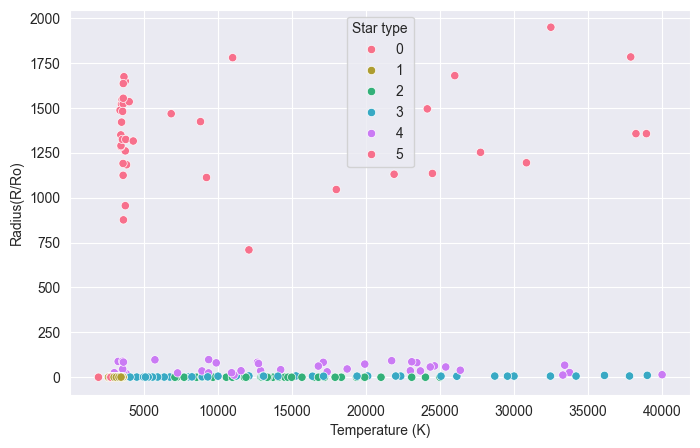

In [35]:
sns.scatterplot(data= df,x = 'Temperature (K)',y= 'Radius(R/Ro)',hue= 'Star type',palette='husl')


In [36]:
cols= ['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)',
       'Absolute magnitude(Mv)']

<Axes: >

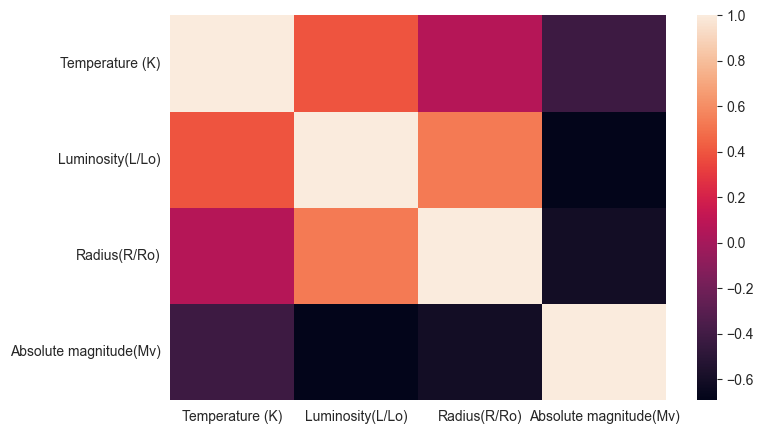

In [37]:
sns.heatmap(df[cols].corr())

In [38]:
X = df.drop(columns=['Star type'])


In [39]:
y = df['Star type']

In [58]:
X,y

(     Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  Absolute magnitude(Mv)  \
 0               3068          0.002400        0.1700                   16.12   
 1               3042          0.000500        0.1542                   16.60   
 2               2600          0.000300        0.1020                   18.70   
 3               2800          0.000200        0.1600                   16.65   
 4               1939          0.000138        0.1030                   20.06   
 ..               ...               ...           ...                     ...   
 235            38940     374830.000000     1356.0000                   -9.93   
 236            30839     834042.000000     1194.0000                  -10.63   
 237             8829     537493.000000     1423.0000                  -10.73   
 238             9235     404940.000000     1112.0000                  -11.23   
 239            37882     294903.000000     1783.0000                   -7.80   
 
      Spectral Class  colo

In [40]:
from sklearn.model_selection import train_test_split

In [57]:
# test train split and X_test,Y_test,X_train,Y_test are made

In [41]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size = 0.2,random_state= 42,stratify=  y)

In [42]:
from sklearn.preprocessing import StandardScaler

In [43]:
scalar = StandardScaler()


In [44]:
X_train[cols] = scalar.fit_transform(X_train[cols])

In [46]:
X_train[cols]

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv)
91,-0.614764,-0.589442,-0.458660,0.205587
202,0.552616,-0.589443,-0.460331,0.753577
237,-0.134347,2.568902,2.325206,-1.444510
123,-0.768837,-0.589443,-0.460171,1.202576
150,2.180204,0.515257,-0.448569,-0.801167
...,...,...,...,...
178,0.230850,0.115685,0.927337,-1.167834
196,-0.769283,-0.589443,-0.459848,0.934517
145,-0.123741,-0.589443,-0.460336,1.006318
229,1.306902,3.811085,-0.280261,-1.120541


In [47]:
X_test[cols] = scalar.transform(X_test[cols])

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
model = RandomForestClassifier(n_estimators= 100,random_state=42)


In [50]:
model.fit(X_train,Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [51]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay

In [52]:
y_predict = model.predict(X_test)

In [53]:
accuracy_score(Y_test,y_predict)

1.0

In [56]:
classification_report(Y_test,y_predict)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00         8\n           1       1.00      1.00      1.00         8\n           2       1.00      1.00      1.00         8\n           3       1.00      1.00      1.00         8\n           4       1.00      1.00      1.00         8\n           5       1.00      1.00      1.00         8\n\n    accuracy                           1.00        48\n   macro avg       1.00      1.00      1.00        48\nweighted avg       1.00      1.00      1.00        48\n'

In [55]:
print(classification_report(Y_test,y_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00         8

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



In [61]:
import matplotlib.pyplot as plt

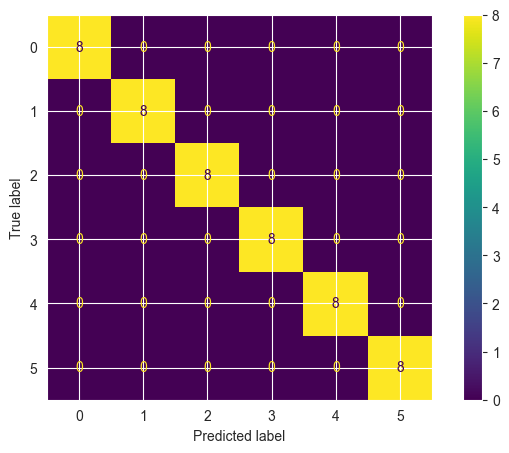

In [64]:
ConfusionMatrixDisplay(confusion_matrix(Y_test,y_predict)).plot(cmap='viridis')
plt.show()